In [1]:
from nilearn.datasets import fetch_abide_pcp

def load_abide(n_subjects=20):
    data = fetch_abide_pcp(
        data_dir='../data/',
        pipeline='cpac',
        band_pass_filtering=True,
        global_signal_regression=True,
        n_subjects=n_subjects
    )
    return data

## fMRI → ROI → Time Series → Graph → Coarsening → ML Model → Prediction

In [2]:
data = load_abide(20)

[fetch_abide_pcp] Dataset found in ..\data\ABIDE_pcp


In [3]:
print(data.keys())

dict_keys(['description', 'phenotypic', 'func_preproc'])


In [4]:
import os
print(os.getcwd())

C:\Users\nitin\Final Year Project\src


In [5]:
print(data.func_preproc[0])

..\data\ABIDE_pcp\cpac\filt_global\Pitt_0050003_func_preproc.nii.gz


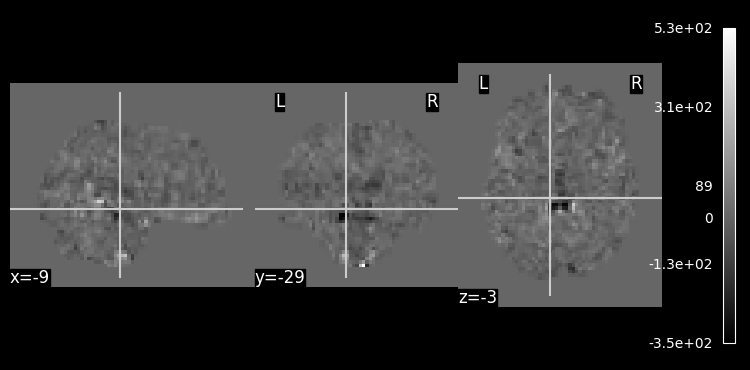

In [6]:
from nilearn import image, plotting

img_3d = image.index_img(data.func_preproc[0], 0)  # first time point
plotting.plot_epi(img_3d)

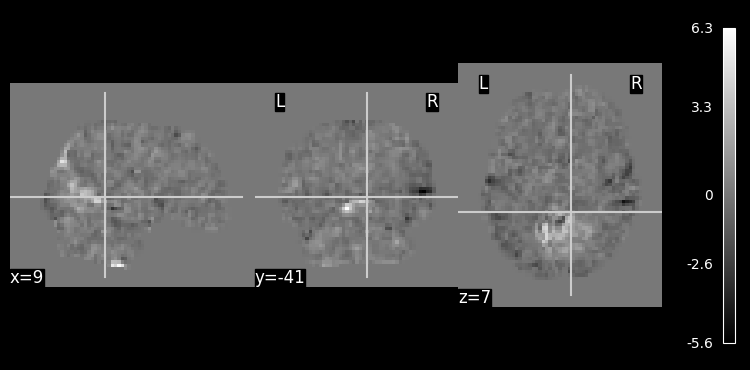

In [7]:
from nilearn import image, plotting

mean_img = image.mean_img(data.func_preproc[0])
plotting.plot_epi(mean_img)

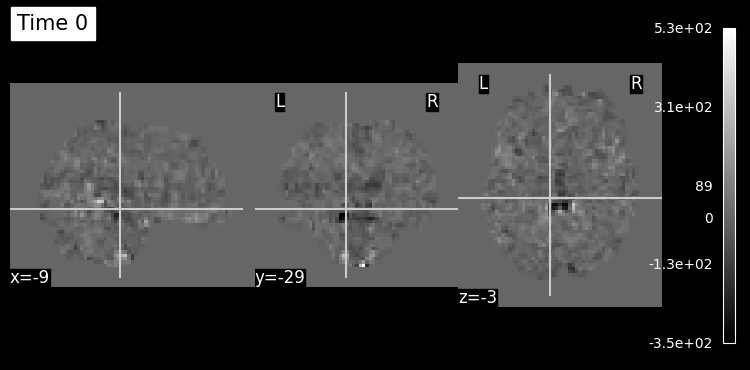

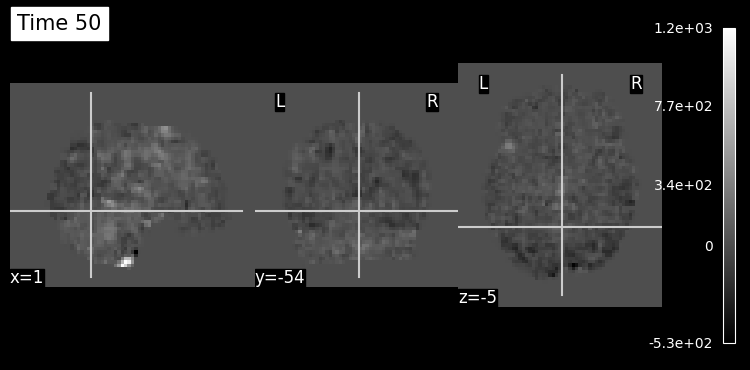

In [8]:
from nilearn import image, plotting

img_t0 = image.index_img(data.func_preproc[0], 0)
img_t50 = image.index_img(data.func_preproc[0], 50)

plotting.plot_epi(img_t0, title="Time 0")
plotting.plot_epi(img_t50, title="Time 50")

In [9]:
from nilearn import image

img = image.load_img(data.func_preproc[0])
print(img.shape)

(61, 73, 61, 196)


| Dimension | Meaning                      |
| --------- | ---------------------------- |
| 61        | brain width                  |
| 73        | brain height                 |
| 61        | brain depth                  |
| 176       | time points (VERY IMPORTANT) |


61 × 73 × 61 ≈ 271,000 voxels 🧠